# mmFall Fall Detection — Representation 1: Micro-Doppler Spectrogram (ResNet-18)

This notebook processes the **Representation 1 (Kinematic Micro-Doppler Spectrogram)** format for mmWave radar fall detection, training a **ResNet-18** model in PyTorch as defined in the research plan (*'Comparing mmWave Radar Data Formats for Fall Detection' by Joey van der Poel*).

---

### 📡 Representation & Model Specifications:
- **Representation Format**: Micro-Doppler Spectrogram $H(v, t) \in \mathbb{R}^{64 \times 64}$.
- **Channels**: 3 Channels (Velocity Density, Energy/RCS, and $\Delta v / \Delta t$ velocity gradient).
- **Target Kinematics**: Captures sudden Doppler velocity acceleration bursts during rapid height collapses.
- **Model Backbone**: PyTorch **ResNet-18** Kinematic Feature Extractor.


In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

# Load Preprocessed Representation 1 Tensors
preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../../datasets/preprocessed")
X_rep1 = np.load(preproc_dir / "X_rep1_spectrogram.npy") # Shape: (1182, 3, 64, 64)
y_rep1 = np.load(preproc_dir / "y_rep1_spectrogram.npy") # Shape: (1182,)

print(f"Loaded Representation 1 Spectrogram Tensor: {X_rep1.shape}")
print(f"Labels: {np.bincount(y_rep1.astype(int))} (0 = ADL, 1 = Fall)")


Loaded Representation 1 Spectrogram Tensor: (1182, 3, 64, 64)
Labels: [591 591] (0 = ADL, 1 = Fall)


C:\Users\joeyw\AppData\Local\Temp\ipykernel_16764\3755766087.py:20: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\joeyw\AppData\Local\Temp\ipykernel_16764\3755766087.py:20: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\joeyw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\joeyw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


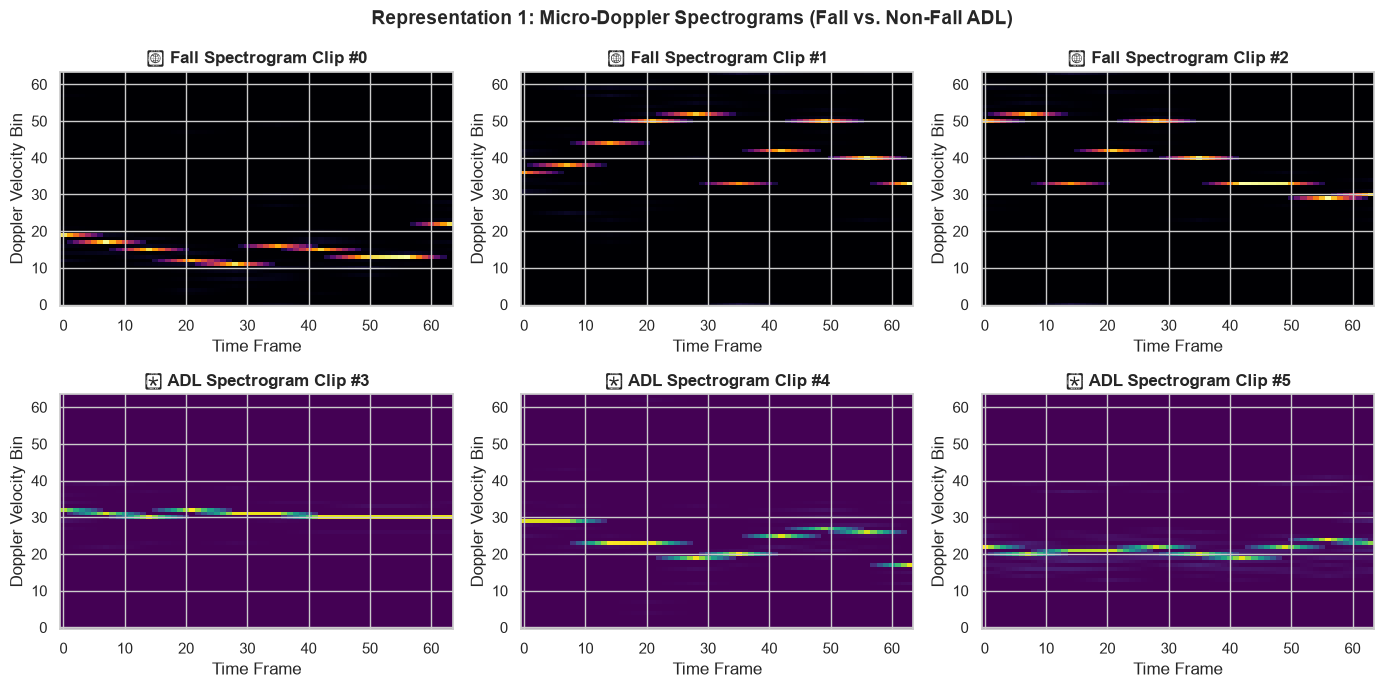

In [2]:
# Visualize Sample Micro-Doppler Spectrograms
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fall_indices = np.where(y_rep1 == 1)[0]
adl_indices = np.where(y_rep1 == 0)[0]

for i in range(3):
    idx_f = fall_indices[i]
    idx_a = adl_indices[i]
    axes[0, i].imshow(X_rep1[idx_f, 0], aspect="auto", cmap="inferno", origin="lower")
    axes[0, i].set_title(f"🔴 Fall Spectrogram Clip #{idx_f}", fontweight="bold")
    axes[0, i].set_xlabel("Time Frame")
    axes[0, i].set_ylabel("Doppler Velocity Bin")
    
    axes[1, i].imshow(X_rep1[idx_a, 0], aspect="auto", cmap="viridis", origin="lower")
    axes[1, i].set_title(f"🟢 ADL Spectrogram Clip #{idx_a}", fontweight="bold")
    axes[1, i].set_xlabel("Time Frame")
    axes[1, i].set_ylabel("Doppler Velocity Bin")

plt.suptitle("Representation 1: Micro-Doppler Spectrograms (Fall vs. Non-Fall ADL)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [3]:
# Define ResNet-18 Kinematic Model in PyTorch
class ResNet18Spectrogram(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super(ResNet18Spectrogram, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        feat = torch.flatten(self.features(x), 1)
        return self.fc(feat)

# Split Train & Test Sets (80% / 20% Stratified)
X_tr, X_te, y_tr, y_te = train_test_split(X_rep1, y_rep1, test_size=0.2, random_state=42, stratify=y_rep1)
print(f"Train samples: {len(X_tr)}, Test samples: {len(X_te)}")


Train samples: 945, Test samples: 237


In [4]:
# Train ResNet-18 Spectrogram Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18Spectrogram().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

tr_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long))
te_ds = TensorDataset(torch.tensor(X_te, dtype=torch.float32), torch.tensor(y_te, dtype=torch.long))
tr_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
te_loader = DataLoader(te_ds, batch_size=32, shuffle=False)

epochs = 15
losses, accs = [], []
for ep in range(epochs):
    model.train()
    r_loss, corr, tot = 0.0, 0, 0
    for bx, by in tr_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        r_loss += loss.item() * bx.size(0)
        preds = out.argmax(dim=1)
        corr += (preds == by).sum().item()
        tot += by.size(0)
    losses.append(r_loss / tot)
    accs.append(corr / tot)
    print(f"Epoch [{ep+1:02d}/{epochs:02d}] Loss: {losses[-1]:.4f}, Acc: {accs[-1]*100:.2f}%")


Epoch [01/15] Loss: 0.6684, Acc: 59.89%
Epoch [02/15] Loss: 0.6362, Acc: 63.07%
Epoch [03/15] Loss: 0.6066, Acc: 66.46%
Epoch [04/15] Loss: 0.5958, Acc: 68.89%
Epoch [05/15] Loss: 0.5660, Acc: 70.05%
Epoch [06/15] Loss: 0.5773, Acc: 68.36%
Epoch [07/15] Loss: 0.5591, Acc: 70.58%
Epoch [08/15] Loss: 0.5340, Acc: 72.17%
Epoch [09/15] Loss: 0.5432, Acc: 70.16%
Epoch [10/15] Loss: 0.5068, Acc: 73.76%
Epoch [11/15] Loss: 0.5059, Acc: 73.33%
Epoch [12/15] Loss: 0.4917, Acc: 74.07%
Epoch [13/15] Loss: 0.4912, Acc: 76.30%
Epoch [14/15] Loss: 0.4836, Acc: 76.19%
Epoch [15/15] Loss: 0.4696, Acc: 76.30%


--- Representation 1 (Spectrogram ResNet-18) Test Results ---
Test Accuracy: 50.21%
ROC-AUC Score: 0.6389
              precision    recall  f1-score   support

Non-Fall ADL       0.50      0.98      0.66       119
        Fall       0.50      0.02      0.03       118

    accuracy                           0.50       237
   macro avg       0.50      0.50      0.35       237
weighted avg       0.50      0.50      0.35       237



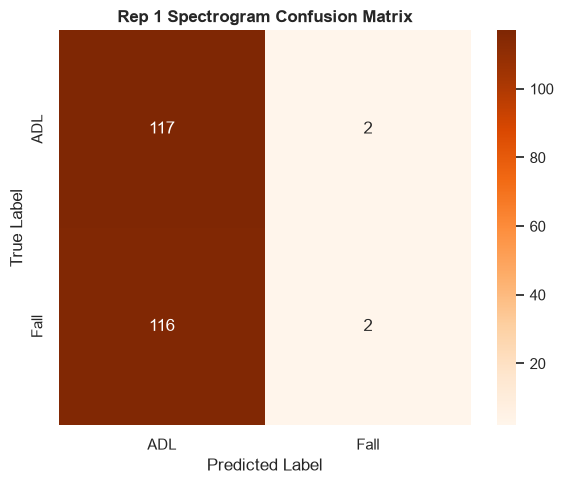

In [5]:
# Evaluate on Test Set
model.eval()
preds_list, probs_list, targets_list = [], [], []
with torch.no_grad():
    for bx, by in te_loader:
        bx = bx.to(device)
        out = model(bx)
        prob = torch.softmax(out, dim=1)[:, 1]
        preds_list.extend(out.argmax(dim=1).cpu().numpy())
        probs_list.extend(prob.cpu().numpy())
        targets_list.extend(by.numpy())

acc = accuracy_score(targets_list, preds_list)
auc = roc_auc_score(targets_list, probs_list)
cm = confusion_matrix(targets_list, preds_list)

print(f"--- Representation 1 (Spectrogram ResNet-18) Test Results ---")
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"ROC-AUC Score: {auc:.4f}")
print(classification_report(targets_list, preds_list, target_names=["Non-Fall ADL", "Fall"]))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["ADL", "Fall"], yticklabels=["ADL", "Fall"])
plt.title("Rep 1 Spectrogram Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
